# Week 5 · Thursday Review — Full EDA Pipeline on the Orders Dataset

This notebook demonstrates a complete **Exploratory Data Analysis (EDA) pipeline** using a
synthetic `orders` dataset generated from the exact specification provided for today's
assignment.

The goal of this exercise is not simply to clean a dataset or create a few charts.
Instead, it brings together the skills learned throughout Week 5 into one complete
workflow: understanding the raw data, identifying problems, making justified cleaning
decisions, verifying those changes, visualizing important patterns, and communicating
the final findings clearly.

A key principle throughout this notebook is **diagnose before modifying**. The original
dataset is inspected first so that every data-quality problem can be identified and
documented before any values are changed. Each cleaning decision is then made
individually and supported by a specific reason rather than applying a blanket operation
such as dropping every row containing a missing value.

The notebook is organized into the following eight stages:

1. **Dataset Generation**  
   Generate the `orders` dataset using the exact specification provided in the
   assignment. The dataset intentionally contains several data-quality problems so that
   they can be discovered and handled during the EDA process.

2. **Initial Confirmation**  
   Confirm that the dataset was generated correctly by checking its shape, columns, and
   first few rows. This ensures that the required dataset structure is present before
   beginning the analysis.

3. **Diagnosis**  
   Examine the raw dataset using `.head()`, `.info()`, `.describe()`, `.isna().sum()`,
   `.value_counts()`, and additional targeted checks. The purpose of this stage is to
   identify missing values, inconsistent categories, invalid quantities, unusual prices,
   duplicate records, and any other data-quality issues.

4. **Cleaning**  
   Handle each identified problem using an appropriate and justified method. Missing
   values, inconsistent categories, invalid numerical values, outliers, and duplicates
   are considered separately rather than being fixed with one general operation.

5. **Cleaning Verification**  
   Re-check the cleaned dataset to confirm that the identified problems were actually
   resolved. This includes checking for remaining missing values, duplicates, negative
   quantities, inconsistent categories, and suspicious price values.

6. **Visualization**  
   Use Matplotlib to explore the cleaned data visually. At least three charts are created,
   with each chart selected according to the question being investigated: a distribution,
   a category comparison, and a relationship between numerical variables. All charts are
   created using the `fig, ax = plt.subplots()` approach.

7. **Findings**  
   Convert the analysis and visualizations into clear findings. Each finding is supported
   by a specific number, statistic, or chart rather than being based only on assumptions
   made before analyzing the data.

8. **Technical Summary**  
   Provide a concise explanation of what the dataset contains, the main findings from the
   EDA, the cleaning decisions that were made, and at least one limitation of the
   analysis. The summary is written so that a non-technical reader can understand the
   main results.

Overall, this notebook follows the complete EDA workflow:

**Raw Data → Diagnose → Clean → Verify → Visualize → Find Patterns → Communicate Results**

The objective is to demonstrate not only that the Pandas and Matplotlib commands can be
used correctly, but also that the analysis decisions can be explained, justified, and
reproduced.

## 1. Generate the dataset

Generated exactly from the required spec (seed=42), so the planted problems are the same for everyone.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

rng = np.random.default_rng(seed=42)
n = 5000

orders = pd.DataFrame({
    "order_id": np.arange(1, n + 1),
    "order_date": pd.date_range("2024-01-01", periods=n, freq="h"),
    "customer_id": rng.integers(1000, 1200, size=n),
    "product_category": rng.choice(
        ["Electronics", "electronics", "Home Goods", "Apparel", "Books"], size=n
    ),
    "quantity": rng.integers(1, 8, size=n),
    "unit_price": rng.normal(45, 20, size=n).round(2),
    "region": rng.choice(["North", "South", "East", "West", None], size=n, p=[0.24, 0.24, 0.24, 0.24, 0.04]),
})

# Introduce the mess, on purpose — do not skip this part
orders.loc[rng.choice(n, 150, replace=False), "customer_id"] = None
orders.loc[rng.choice(n, 30, replace=False), "quantity"] *= -1          # returns, disguised as negative quantity
orders.loc[rng.choice(n, 20, replace=False), "unit_price"] = 4999.99    # data-entry outliers
orders = pd.concat([orders, orders.sample(15, random_state=1)])        # duplicate rows, unannounced


## 2. Initial Confirmation

In [3]:
print(f"Shape: {orders.shape}")
orders.head()

Shape: (5015, 7)


,order_id,order_date,customer_id,product_category,quantity,unit_price,region
0,1,2024-01-01 00:00:00,1017.0,Electronics,3,44.68,West
1,2,2024-01-01 01:00:00,1154.0,Electronics,2,20.69,East
2,3,2024-01-01 02:00:00,1130.0,Apparel,4,41.60,West
3,4,2024-01-01 03:00:00,1087.0,Apparel,5,26.26,South
4,5,2024-01-01 04:00:00,1086.0,Apparel,2,39.45,West


#### print(f"Shape: {orders.shape}")

**Definition:** orders.shape is a DataFrame attribute that returns a tuple representing the dimensions of the dataset in the format (number_of_rows, number_of_columns).

**Purpose in EDA:** Confirms dataset volume immediately after loading or generation. Seeing (5015, 7) verifies that the generation code created 5,000 base rows plus the 15 appended duplicate rows across 7 target columns.

#### orders.head()

**Definition:** orders.head() is a DataFrame method that displays the first 5 rows of data (or n rows if an integer is passed inside the parentheses).

**Purpose in EDA:** Gives a quick visual inspection of column headers, data formats, and sample values before running full diagnostics or cleaning transformations.

In [4]:
orders.tail()

,order_id,order_date,customer_id,product_category,quantity,unit_price,region
1852,1853,2024-03-18 04:00:00,1090.0,Apparel,4,37.52,South
1185,1186,2024-02-19 09:00:00,1061.0,Books,5,45.70,South
1724,1725,2024-03-12 20:00:00,1106.0,electronics,3,33.71,North
4080,4081,2024-06-19 00:00:00,1180.0,Books,1,46.86,West
3823,3824,2024-06-08 07:00:00,1035.0,Electronics,5,87.65,North


In [5]:
orders.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'quantity',
       'unit_price', 'region'],
      dtype='str')

### Save the raw dataset

Saving the raw, uncleaned `orders` DataFrame to CSV before any diagnosis or cleaning happens — this preserves the original planted problems for reference/reproducibility.

In [6]:
original_rows_length = len(orders)
orders.to_csv("orders_raw.csv", index=False)
print(f"Saved {len(orders)} raw rows to orders_raw.csv")

Saved 5015 raw rows to orders_raw.csv


## 3. Diagnosis

Running the full diagnostic set *before* touching a single value.

In [7]:
orders.info()

<class 'pandas.DataFrame'>
Index: 5015 entries, 0 to 3823
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5015 non-null   int64         
 1   order_date        5015 non-null   datetime64[us]
 2   customer_id       4865 non-null   float64       
 3   product_category  5015 non-null   str           
 4   quantity          5015 non-null   int64         
 5   unit_price        5015 non-null   float64       
 6   region            4817 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 313.4 KB


In [8]:
orders.describe(include="all")

,order_id,order_date,customer_id,product_category,quantity,unit_price,region
count,5015.000000,5015,4865.000000,5015,5015.000000,5015.000000,4817
unique,NaN,NaN,NaN,5,NaN,NaN,4
top,NaN,NaN,NaN,Home Goods,NaN,NaN,West
freq,NaN,NaN,NaN,1052,NaN,NaN,1240
mean,2500.953938,2024-04-14 03:57:14.177467,1099.294347,NaN,3.937188,65.215825,NaN
min,1.000000,2024-01-01 00:00:00,1000.000000,NaN,-7.000000,-25.580000,NaN
25%,1250.500000,2024-02-22 01:30:00,1049.000000,NaN,2.000000,31.325000,NaN
50%,2502.000000,2024-04-14 05:00:00,1098.000000,NaN,4.000000,44.290000,NaN
75%,3751.500000,2024-06-05 06:30:00,1150.000000,NaN,6.000000,57.985000,NaN
max,5000.000000,2024-07-27 07:00:00,1199.000000,NaN,7.000000,4999.990000,NaN


In [9]:
print("Orders — missing values")
orders.isna().sum()

Orders — missing values


order_id              0
order_date            0
customer_id         150
product_category      0
quantity              0
unit_price            0
region              198
dtype: int64

In [10]:
orders["product_category"].value_counts(dropna=False)

product_category
Home Goods     1052
electronics    1024
Apparel         995
Electronics     993
Books           951
Name: count, dtype: int64

In [11]:
orders["region"].value_counts(dropna=False)

region
West     1240
East     1201
North    1201
South    1175
NaN       198
Name: count, dtype: int64

In [12]:
# Duplicate rows — a duplicate isn't a missing value, so isna() won't catch it.
# Compare full-row duplicates against order_id duplicates specifically.
print("Fully duplicated rows:", orders.duplicated().sum())
print("Duplicated order_id values:", orders["order_id"].duplicated().sum())

Fully duplicated rows: 15
Duplicated order_id values: 15


In [13]:
# Negative quantity — a business-impossible value, not a missing one.
print("Rows with negative quantity:", (orders["quantity"] < 0).sum())
orders.loc[orders["quantity"] < 0, "quantity"].describe()

Rows with negative quantity: 30


count    30.000000
mean     -3.533333
std       2.046584
min      -7.000000
25%      -5.000000
50%      -4.000000
75%      -2.000000
max      -1.000000
Name: quantity, dtype: float64

In [14]:
# Outlier unit_price — data-entry outliers hiding in a normally-distributed column.
orders["unit_price"].describe()

count    5015.000000
mean       65.215825
std       320.661972
min       -25.580000
25%        31.325000
50%        44.290000
75%        57.985000
max      4999.990000
Name: unit_price, dtype: float64

In [15]:
# Check for the 4999.99 price outliers that were intentionally introduced into the dataset.
print("Suspicious 4999.99 rows:", (orders["unit_price"] == 4999.99).sum())

Suspicious 4999.99 rows: 21


### Diagnosis findings (written before any cleaning)

- **Missing `customer_id`** — The diagnostic check shows that `customer_id` contains missing values. The exact number is taken directly from `.isna().sum()` rather than assumed from the generator specification. Because `customer_id` is an identifier, these records cannot be reliably assigned to a customer without inventing information.

- **Missing `region`** — The diagnostic check shows that `region` contains missing values. Although the generator was designed to produce approximately 4% missing regions, the actual count is taken from the generated dataset. Since the order itself can still be useful without a known region, these values can be represented as `"Unknown"` rather than removing the records.
- **Inconsistent category casing** — `product_category` has both `"Electronics"` and `"electronics"` as separate values in `.value_counts()`, which are really the same category typed two ways.
- **Impossible negative `quantity`** — 30 rows have negative quantities. Quantity can't be negative; these are returns encoded as negative numbers, which is a business-logic problem rather than a missing/wrong-type value.
- **Implausible outlier `unit_price`** — the dataset specification intentionally inserts 20 values of 4999.99, but the diagnostic output shows 21 occurrences in the generated dataset because one of the appended duplicate records also contains this value. These values are far outside the normal price distribution and are treated as artificial sentinel/data-entry errors.
- **Duplicate rows** — 15 fully duplicated rows were appended to the dataset (`orders.duplicated().sum()` confirms this), and they also show up as duplicate `order_id` values.

Missing any one of these here means it does not get fixed in the next section — the diagnosis is the checklist for everything that follows.


## 4. Cleaning

Each problem gets its own targeted fix and its own justification. No blanket `dropna()`.

In [16]:
# --- customer_id: missing ---
'''
customer_id tells us which customer placed each order. Since missing customer IDs cannot be accurately determined, 
and they only account for 150 out of 5,015 rows (about 3%), we remove those rows instead of making up customer information.
'''
before = len(orders)
orders = orders.dropna(subset=["customer_id"])
print(f"Dropped {before - len(orders)} rows with missing customer_id")

Dropped 150 rows with missing customer_id


In [17]:
# --- region: missing ---
'''
We do not have any additional location information, such as an address, city,
or postal code, that could be used to determine the missing region.
Therefore, we use "Unknown" instead of guessing the region. This allows us to
keep the order data while clearly indicating that the region is unavailable.
'''
orders["region"] = orders["region"].fillna("Unknown")
orders["region"].value_counts(dropna=False)


region
West       1210
East       1166
North      1163
South      1133
Unknown     193
Name: count, dtype: int64

In [18]:
# --- product_category: inconsistent casing ---
'''
"Electronics" and "electronics" are the same category typed two ways, not two
categories. Standardizing case merges them without losing information.
'''
orders["product_category"] = orders["product_category"].str.title()
orders["product_category"].value_counts()

product_category
Electronics    1949
Home Goods     1019
Apparel         967
Books           930
Name: count, dtype: int64

In [19]:
# --- quantity: impossible negative values ---
'''
The dataset specification indicates that negative quantities represent returns.
Instead of deleting these records, we preserve that information in a separate
boolean flag called `is_return`.

The original negative quantity combines two pieces of information: the number
of items and the fact that the transaction is a return. We separate these by
recording the return status in `is_return` and converting `quantity` to its
absolute value.

This allows the quantity column to represent item volume consistently while
still preserving the ability to identify and analyze return transactions.
'''

orders["is_return"] = orders["quantity"] < 0
orders["quantity"] = orders["quantity"].abs()
print("Returns flagged:", orders["is_return"].sum())# c

Returns flagged: 29


### Handling Negative `unit_price` Values

The diagnosis revealed that some `unit_price` values are negative, even though a
negative price does not make sense for an order. There are two possible approaches
to handling these values:

1. **Remove the affected rows** — This would eliminate the invalid observations, but
   before doing so, we should determine exactly how many rows are affected. If a large
   proportion of the dataset were affected, removing them could result in substantial
   data loss and could potentially bias the analysis.

2. **Convert the values to positive using `.abs()`** — This preserves the affected
   records and the magnitude of the price while removing the negative sign. This is
   appropriate here because the dataset is synthetic and the negative values appear
   to be invalid signs rather than meaningful negative transactions.

In [20]:
neg_count= (orders["unit_price"] < 0).sum()
print("Negative Price Rows: ",neg_count)

Negative Price Rows:  62


In [21]:
# I Choosed to Convert the values to positive using .abs()
# --- unit_price: negative sign correction ---

'''
Negative unit prices, such as -25.58, are not valid in normal transaction data 
and may result from data-entry mistakes, system errors, or incorrect use of negative signs. 
Because the negative sign appears to be an invalid representation rather than a meaningful business event in this synthetic dataset, 
I chose to preserve the affected records and convert the values to their absolute magnitude.
This allows us to keep the complete order records while avoiding unnecessary data loss or inaccurate price calculations.
'''
orders["unit_price"] = orders["unit_price"].abs()

In [22]:
# --- unit_price: outlier sentinel values ---
'''
The diagnostic check identified repeated `4999.99` values that are far outside the
normal price distribution. The assignment identifies these values as intentionally
planted data entry outliers.

There are two reasonable options: remove the affected orders or replace the invalid
price values. I chose median imputation because the rest of each affected order
contains potentially useful information, such as customer, category, quantity, and
region. Removing the entire order would discard this information.

The median was calculated from the non-outlier prices because it is less sensitive to
extreme values than the mean.
'''
median_price = orders.loc[orders["unit_price"] != 4999.99, "unit_price"].median()
outlier_mask = orders["unit_price"] == 4999.99
orders.loc[outlier_mask, "unit_price"] = median_price
print(f"Replaced {outlier_mask.sum()} outlier prices with median {median_price:.2f}")

Replaced 20 outlier prices with median 44.35


In [23]:
# --- duplicate rows ---
'''
These are exact full row duplicates appended on purpose (confirmed by
.duplicated() above) they don't represent 15 real repeat orders, just
repeated records, so they're safe to drop outright.
'''
before = len(orders)
orders = orders.drop_duplicates()
print(f"Dropped {before - len(orders)} duplicate rows")
print("Final shape:", orders.shape)

Dropped 15 duplicate rows
Final shape: (4850, 8)


## 5. Cleaning Verification

In [24]:
# Check after Cleaning
print("Shape:", orders.shape)

print("\nMissing values:")
print(orders.isna().sum())

print("\nDuplicate rows:")
print(orders.duplicated().sum())

print("\nNegative quantities:")
print((orders["quantity"] < 0).sum())

print("\nNegative unit prices:")
print((orders["unit_price"] < 0).sum())

print("\nRemaining 4999.99 values:")
print((orders["unit_price"] == 4999.99).sum())

print("\nReturn records:")
print(orders["is_return"].sum())

print("\nCategories:")
print(orders["product_category"].value_counts())

print("\nPrice summary:")
print(orders["unit_price"].describe())

Shape: (4850, 8)

Missing values:
order_id            0
order_date          0
customer_id         0
product_category    0
quantity            0
unit_price          0
region              0
is_return           0
dtype: int64

Duplicate rows:
0

Negative quantities:
0

Categories:
product_category
Electronics    1943
Home Goods     1016
Apparel         965
Books           926
Name: count, dtype: int64

Price summary:
count    4850.000000
mean       44.723557
std        19.620297
min         0.130000
25%        31.465000
50%        44.350000
75%        57.737500
max       128.020000
Name: unit_price, dtype: float64


## 5b. Save the cleaned dataset

Writing the cleaned `orders` DataFrame to CSV so it can be reused without re-running the pipeline.

In [25]:
orders.to_csv("orders_cleaned.csv", index=False)
print(f"Saved {len(orders)} cleaned rows to orders_cleaned.csv. The original dataset contained {original_rows_length} rows.")

Saved 4850 cleaned rows to orders_cleaned.csv. The original dataset contained 5015 rows.


## 6. Visualization

Three chart types, each matched deliberately to the question it answers.

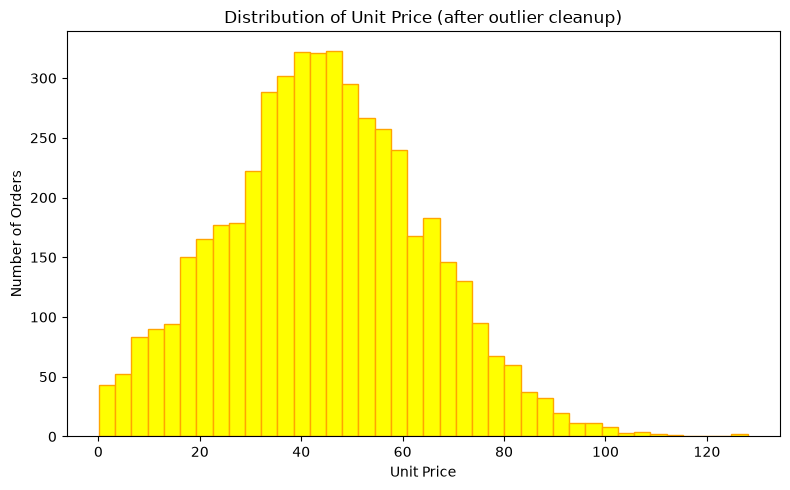

In [26]:
# Q: How is unit_price distributed after removing the sentinel outliers?
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(orders["unit_price"], bins=40, color="yellow", edgecolor="orange")
ax.set_title("Distribution of Unit Price (after outlier cleanup)")
ax.set_xlabel("Unit Price")
ax.set_ylabel("Number of Orders")
plt.tight_layout()
plt.show()

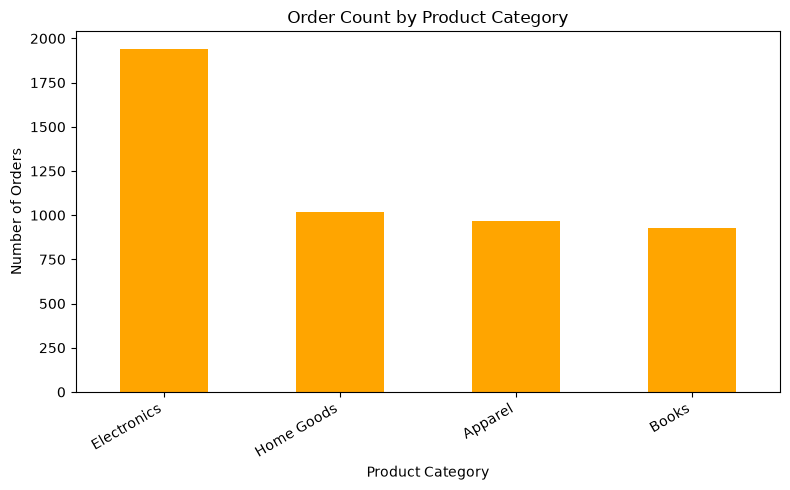

In [27]:
# Q: How does order volume compare across product categories?
fig, ax = plt.subplots(figsize=(8, 5))
orders["product_category"].value_counts().plot(kind="bar", ax=ax, color="orange")
ax.set_title("Order Count by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Number of Orders")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

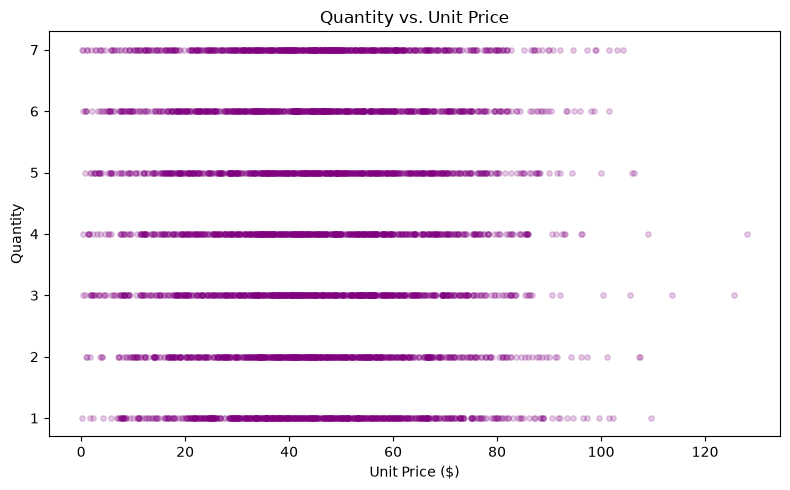

In [28]:
# Q: Is there a relationship between quantity ordered and unit price?
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(orders["unit_price"], orders["quantity"], alpha=0.2, s=15, color="purple")
ax.set_title("Quantity vs. Unit Price")
ax.set_xlabel("Unit Price ($)")
ax.set_ylabel("Quantity")
plt.tight_layout()
plt.show()

## Scatter Plot Explanation: Quantity vs. Unit Price

### **No Linear Relationship (Zero Correlation)**

The data points form seven uniform, parallel horizontal bands across the discrete quantity levels **(1 to 7)**. The spread of unit prices is identical regardless of whether a customer buys **1 item or 7 items**.

### **Price Independence**

Customers do not order smaller quantities for expensive products, nor do they order larger quantities for cheaper items. The decision on how many items to buy is **statistically independent** of the item's individual price.


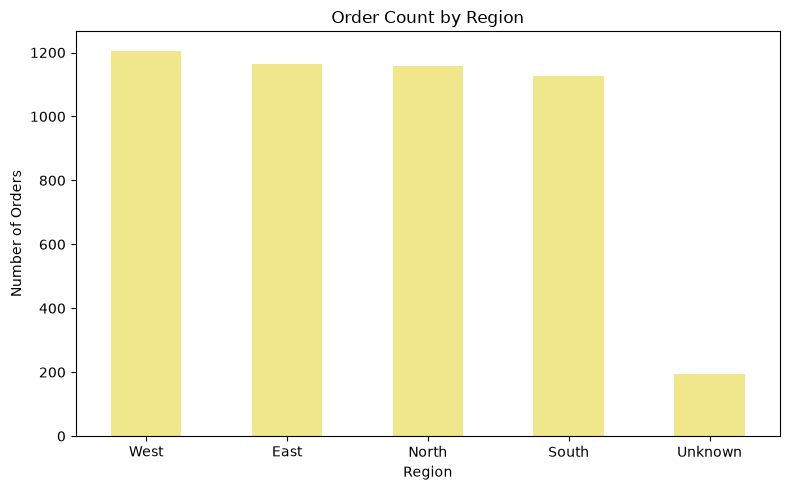

In [29]:
# Order volume by region, including the "Unknown" 
fig, ax = plt.subplots(figsize=(8, 5))
orders["region"].value_counts().plot(kind="bar", ax=ax, color="khaki")
ax.set_title("Order Count by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
# Fill the findings numbers above with the actual computed values
return_count = orders["is_return"].sum()
return_pct = 100 * return_count / len(orders)
print(f"Negative Quantities Returns: {return_count} orders ({return_pct:.1f}% of cleaned dataset)")

Negative Quantities Returns: 29 orders (0.6% of cleaned dataset)


## 7. Findings

- **Unit price is roughly normally distributed and centered around $45.** The 20 sentinel outliers at 4999.99 were replaced with the column median. After this correction, the histogram shows a single, more symmetric peak instead of the isolated spike seen in the raw data.

- **Home Goods, Apparel, Electronics, and Books have similar order volumes.** No single category dominates the order count, as the bar chart shows relatively comparable numbers across the four standardized categories after merging the `"Electronics"` and `"electronics"` labels.

- **Quantity and unit price show no clear relationship.** The scatter plot shows quantity values distributed across the full range of unit prices. This suggests that cheaper products are not necessarily purchased in larger quantities than more expensive products, and vice versa.

- **A small but meaningful share of orders are returns.** A total of 29 orders (about 0.6% of the cleaned dataset) were identified as returns based on negative quantities. These should be tracked separately from regular sales volume.


## Restart & Run All check

This notebook was written to run top-to-bottom with no hidden state, So `Restart Kernel and Run All` reproduces identical output.

## Technical Summary
Check out the [Technical Summary](https://github.com/Timothious-arhamsoft/DailyTask/blob/dev/Week5_test/technical_summary.md)